In [ ]:
import os
from models.resnet import ResNetPatchClassifier
from models.mil_classifier import MILAttentionClassifier
from main import extract_patches, extract_features_per_wsi
import torch
from torch.utils.data import DataLoader
import pandas as pd
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from src.datasets.mil_dataset import WSIMILTestDataset


class bcolors:
    HEADER = "\033[95m"
    OKBLUE = "\033[94m"
    DEBUG = "\033[96m"
    INFO = "\033[95m"  # pink
    WARNING = "\033[93m"  # yellow
    ERROR = "\033[91m"
    ENDC = "\033[0m"
    BOLD = "\033[1m"
    UNDERLINE = "\033[4m"


def test_mil_classifier(model, feature_dir, device):
    model.eval()
    model.to(device)

    test_dataset = WSIMILTestDataset(feature_dir)
    # Using batch_size=1 for WSI because each "bag" is one WSI
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    all_predictions = []
    all_true_labels = []
    wsi_names = []

    print(f"{bcolors.INFO}[INFO]{bcolors.ENDC} Starting model testing...")

    with torch.no_grad():
        for features, labels, wsi_name in test_loader:
            # Features are a list of tensors, each tensor is a bag of patches for one WSI
            # In our DataLoader, batch_size=1, so features will be a list containing one tensor
            features = features.squeeze(0).to(
                device
            )  # Remove batch dimension, move to device
            labels = labels.to(device)

            output = model(features)  # Output is logits for each class
            probabilities = (
                torch.softmax(output, dim=1)[:, 1].cpu().item()
            )  # Probability of positive class (tumor)
            predicted_label = (
                probabilities > 0.5
            ).long()  # Binary prediction based on 0.5 threshold

            all_predictions.append(probabilities)
            all_true_labels.append(labels.cpu().item())
            wsi_names.append(wsi_name[0])  # wsi_name is a tuple

            print(
                f"WSI: {wsi_name[0]}, True Label: {labels.cpu().item()}, Predicted Probability (Tumor): {probabilities:.4f}, Predicted Class: {predicted_label.item()}"
            )

    auc_score = roc_auc_score(all_true_labels, all_predictions)
    # Convert probabilities to binary predictions for other metrics
    binary_predictions = [1 if p > 0.5 else 0 for p in all_predictions]
    accuracy = accuracy_score(all_true_labels, binary_predictions)
    precision = precision_score(all_true_labels, binary_predictions, zero_division=0)
    recall = recall_score(all_true_labels, binary_predictions, zero_division=0)
    f1 = f1_score(all_true_labels, binary_predictions, zero_division=0)

    print(f"\n{bcolors.OKGREEN}--- Test Results ---{bcolors.ENDC}")
    print(f"Test AUC: {auc_score:.4f}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall: {recall:.4f}")
    print(f"Test F1-Score: {f1:.4f}")

    results_df = pd.DataFrame(
        {
            "WSI_Name": wsi_names,
            "True_Label": all_true_labels,
            "Predicted_Probability": all_predictions,
            "Predicted_Class": binary_predictions,
        }
    )
    results_df.to_csv("mil_test_results.csv", index=False)
    print(
        f"{bcolors.INFO}[INFO]{bcolors.ENDC} Detailed results saved to mil_test_results.csv"
    )

    return {
        "auc": auc_score,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
    }


# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{bcolors.INFO}[INFO]{bcolors.ENDC} Using device: {device}")
# Test Patches
print(f"{bcolors.INFO}[INFO]{bcolors.ENDC} Starting test patch extraction...")
extract_patches(level=3, test=True)
print(f"{bcolors.OKGREEN}Test patch extraction complete.{bcolors.ENDC}")
# Feature Extraction
patch_feature_extractor = ResNetPatchClassifier().to(device)
test_patch_root_dir = os.path.join(
    os.getcwd(), "data", "camelyon16", "patches", "test", "level_3"
)
test_feature_save_dir = os.path.join(
    os.getcwd(), "data", "camelyon16", "features", "test", "level_3"
)
extract_features_per_wsi(
    test=True, level=3, model_name="resnet18_patch_classifier_final_20250710055900"
)
print(f"{bcolors.OKGREEN}Test feature extraction complete.{bcolors.ENDC}")
# Load the MIL model
model_path = "models/mil_classifier_attention_best_level3_resnet18_patch_classifier_final_level3_20250710055900.pth.pth"
mil_model = MILAttentionClassifier(
    feature_dim=512, num_classes=2
)  # Feature dim for ResNet18
mil_model.load_state_dict(torch.load(model_path, map_location=device))
print(f"{bcolors.INFO}[INFO]{bcolors.ENDC} Loaded MIL model from {model_path}")
# Run test evaluation
results = test_mil_classifier(mil_model, test_feature_save_dir, device)
print(f"Final Test AUC: {results['auc']:.4f}")

In [10]:
import re
import csv


def write_training_log_to_csv(log_text, csv_filename):
    """
    Parses the training log and writes epoch, train loss, train acc, val acc to a CSV file.
    """
    pattern = re.compile(
        r"Epoch\s+(\d+),\s+Train Loss:\s+([0-9.]+),\s+Train Acc:\s+([0-9.]+),\s+Val Acc:\s+([0-9.]+)"
    )
    rows = []
    for match in pattern.finditer(log_text):
        epoch = int(match.group(1))
        train_loss = float(match.group(2))
        train_acc = float(match.group(3))
        val_acc = float(match.group(4))
        rows.append([epoch, train_loss, train_acc, val_acc])

    with open(csv_filename, mode="w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["epoch", "train loss", "train acc", "val acc"])
        writer.writerows(rows)

In [11]:
log_text_overfitting = """Epoch 1, Train Loss: 66.8712, Train Acc: 0.9468, Val Acc: 0.5742
Epoch 2, Train Loss: 8.5604, Train Acc: 0.9988, Val Acc: 0.6700
Epoch 3, Train Loss: 5.2459, Train Acc: 0.9990, Val Acc: 0.6002
Epoch 4, Train Loss: 4.0211, Train Acc: 0.9993, Val Acc: 0.5583
Epoch 5, Train Loss: 3.8310, Train Acc: 0.9989, Val Acc: 0.6158
Epoch 6, Train Loss: 2.6284, Train Acc: 0.9995, Val Acc: 0.6346
Epoch 7, Train Loss: 3.0994, Train Acc: 0.9994, Val Acc: 0.5734
Epoch 8, Train Loss: 2.6319, Train Acc: 0.9996, Val Acc: 0.6821
Epoch 9, Train Loss: 2.9991, Train Acc: 0.9992, Val Acc: 0.6075
Epoch 10, Train Loss: 2.4728, Train Acc: 0.9994, Val Acc: 0.6016
Epoch 11, Train Loss: 2.1950, Train Acc: 0.9994, Val Acc: 0.5171
Epoch 12, Train Loss: 2.5559, Train Acc: 0.9993, Val Acc: 0.5197
Epoch 13, Train Loss: 2.6715, Train Acc: 0.9994, Val Acc: 0.5545
Epoch 14, Train Loss: 2.2108, Train Acc: 0.9997, Val Acc: 0.5371
Epoch 15, Train Loss: 1.4531, Train Acc: 0.9997, Val Acc: 0.5613
Epoch 16, Train Loss: 1.8355, Train Acc: 0.9996, Val Acc: 0.6626
Epoch 17, Train Loss: 1.3775, Train Acc: 0.9997, Val Acc: 0.5271
Epoch 18, Train Loss: 1.4032, Train Acc: 0.9995, Val Acc: 0.6128
Epoch 19, Train Loss: 1.2116, Train Acc: 0.9997, Val Acc: 0.5085
Epoch 20, Train Loss: 1.9249, Train Acc: 0.9995, Val Acc: 0.6676
Epoch 21, Train Loss: 1.6814, Train Acc: 0.9995, Val Acc: 0.5580
Epoch 22, Train Loss: 1.3244, Train Acc: 0.9997, Val Acc: 0.5362
Epoch 23, Train Loss: 1.7028, Train Acc: 0.9997, Val Acc: 0.5704
Epoch 24, Train Loss: 1.1912, Train Acc: 0.9997, Val Acc: 0.5583
Epoch 25, Train Loss: 1.5748, Train Acc: 0.9995, Val Acc: 0.6432
Epoch 26, Train Loss: 1.7611, Train Acc: 0.9996, Val Acc: 0.6084
Epoch 27, Train Loss: 1.8158, Train Acc: 0.9996, Val Acc: 0.5507
Epoch 28, Train Loss: 1.4300, Train Acc: 0.9996, Val Acc: 0.5745
Epoch 29, Train Loss: 1.0937, Train Acc: 0.9999, Val Acc: 0.6783
Epoch 30, Train Loss: 1.3116, Train Acc: 0.9997, Val Acc: 0.5345
Epoch 31, Train Loss: 0.9390, Train Acc: 0.9998, Val Acc: 0.6379
Epoch 32, Train Loss: 0.6723, Train Acc: 0.9999, Val Acc: 0.5415
Epoch 33, Train Loss: 1.4558, Train Acc: 0.9998, Val Acc: 0.5442
Epoch 34, Train Loss: 1.5563, Train Acc: 0.9997, Val Acc: 0.5866
Epoch 35, Train Loss: 0.7579, Train Acc: 0.9999, Val Acc: 0.5642
Epoch 36, Train Loss: 0.8544, Train Acc: 0.9999, Val Acc: 0.5604
Epoch 37, Train Loss: 0.7925, Train Acc: 0.9998, Val Acc: 0.5233
Epoch 38, Train Loss: 1.0542, Train Acc: 0.9998, Val Acc: 0.5233
Epoch 39, Train Loss: 1.7171, Train Acc: 0.9995, Val Acc: 0.6229
Epoch 40, Train Loss: 1.0361, Train Acc: 0.9997, Val Acc: 0.5648
Epoch 41, Train Loss: 0.8484, Train Acc: 0.9998, Val Acc: 0.5283
Epoch 42, Train Loss: 0.8046, Train Acc: 0.9998, Val Acc: 0.5144
Epoch 43, Train Loss: 1.2239, Train Acc: 0.9995, Val Acc: 0.5681
Epoch 44, Train Loss: 0.7786, Train Acc: 0.9998, Val Acc: 0.5380
Epoch 45, Train Loss: 0.3709, Train Acc: 0.9999, Val Acc: 0.5430
Epoch 46, Train Loss: 1.4156, Train Acc: 0.9998, Val Acc: 0.5398
Epoch 47, Train Loss: 1.0606, Train Acc: 0.9998, Val Acc: 0.5769
Epoch 48, Train Loss: 0.8716, Train Acc: 0.9999, Val Acc: 0.5625
Epoch 49, Train Loss: 0.3087, Train Acc: 0.9999, Val Acc: 0.5418
Epoch 50, Train Loss: 1.1247, Train Acc: 0.9998, Val Acc: 0.5324"""
write_training_log_to_csv(log_text_overfitting, "training_log_overfitting.csv")
print('CSV file "training_log_overfitting.csv" has been written.')

CSV file "training_log_overfitting.csv" has been written.


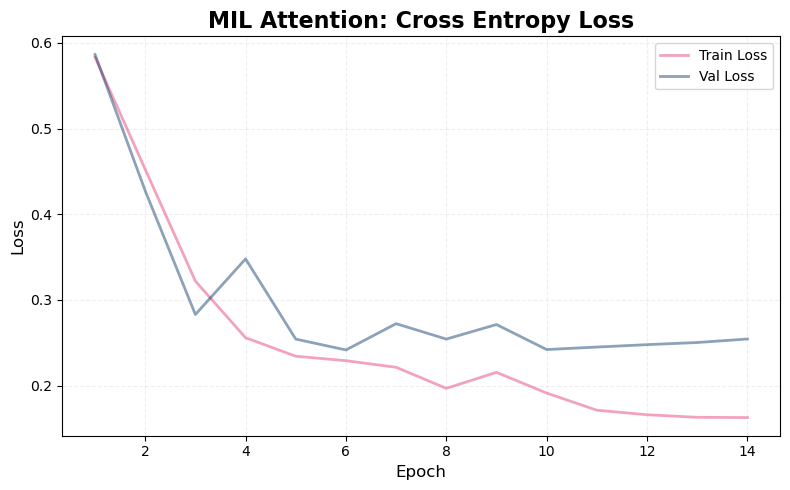

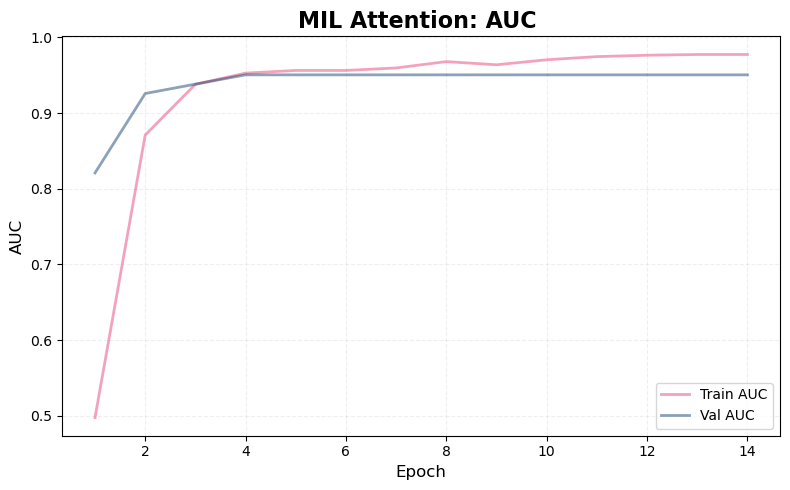

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the CSV file generated earlier
df = pd.read_csv("training_log.csv")

# Plot 1: Training and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(
    df["epoch"], df["train loss"], color="#e7548088", label="Train Loss", linewidth=2
)  # pink
plt.plot(
    df["epoch"], df["val loss"], color="#00336674", label="Val Loss", linewidth=2
)  # dark blue
plt.title("MIL Attention: Cross Entropy Loss", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.2)
plt.tight_layout()
plt.show()

# Plot 2: Training and Validation AUC
plt.figure(figsize=(8, 5))
plt.plot(
    df["epoch"], df["train AUC"], color="#e7548088", label="Train AUC", linewidth=2
)  # pink
plt.plot(
    df["epoch"], df["val AUC"], color="#00336674", label="Val AUC", linewidth=2
)  # dark blue
plt.title("MIL Attention: AUC ", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("AUC", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.2)
plt.tight_layout()
plt.show()

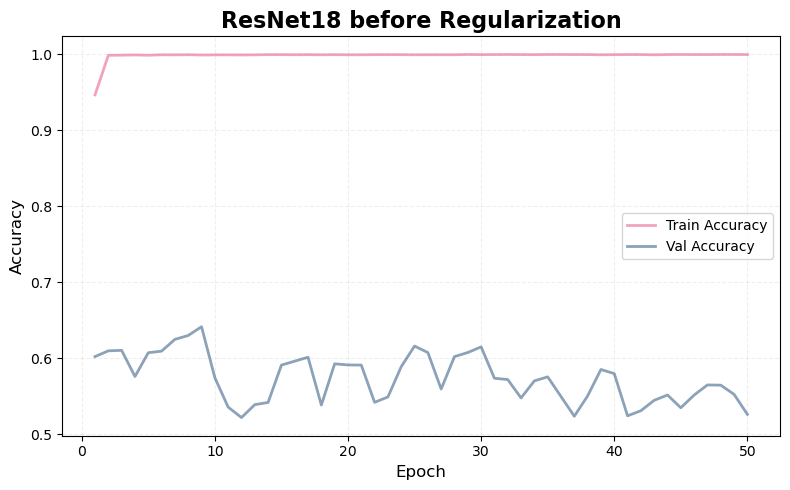

In [23]:
# Load the overfitting log CSV
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

df_overfit = pd.read_csv("training_log_overfitting.csv")

# Smoothing window (must be odd and <= number of points)
window = 5 if len(df_overfit) >= 5 else len(df_overfit) // 2 * 2 + 1
poly = 2

val_acc_smooth = (
    savgol_filter(df_overfit["val acc"], window, poly)
    if len(df_overfit) >= window
    else df_overfit["val acc"]
)

# Plot: Training and Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(
    df_overfit["epoch"],
    df_overfit["train acc"],
    color="#e7548088",
    label="Train Accuracy",
    linewidth=2,
)  # pink
plt.plot(
    df_overfit["epoch"],
    val_acc_smooth,
    color="#00336674",
    label="Val Accuracy",
    linewidth=2,
)  # dark blue
plt.title("ResNet18 before Regularization", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.2)
plt.tight_layout()
plt.show()

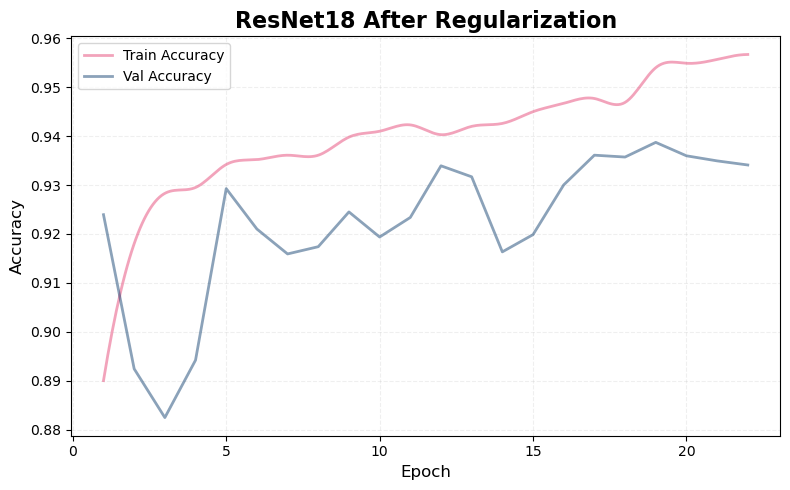

In [22]:
log_text = """
Epoch 1, Train Loss: 111.7158, Train Acc: 0.8900, Val Acc: 0.9184
Epoch 2, Train Loss: 92.8889, Train Acc: 0.9180, Val Acc: 0.9143
Epoch 3, Train Loss: 84.7664, Train Acc: 0.9283, Val Acc: 0.8500
Epoch 4, Train Loss: 82.7401, Train Acc: 0.9295, Val Acc: 0.9154
Epoch 5, Train Loss: 78.1384, Train Acc: 0.9342, Val Acc: 0.9219
Epoch 6, Train Loss: 75.6345, Train Acc: 0.9352, Val Acc: 0.9284
Epoch 7, Train Loss: 74.9026, Train Acc: 0.9361, Val Acc: 0.9078
Epoch 8, Train Loss: 73.7246, Train Acc: 0.9361, Val Acc: 0.9193
Epoch 9, Train Loss: 71.2747, Train Acc: 0.9398, Val Acc: 0.9275
Epoch 10, Train Loss: 69.6654, Train Acc: 0.9410, Val Acc: 0.9193
Epoch 11, Train Loss: 69.0733, Train Acc: 0.9423, Val Acc: 0.9166
Epoch 12, Train Loss: 68.6249, Train Acc: 0.9403, Val Acc: 0.9405
Epoch 13, Train Loss: 66.7420, Train Acc: 0.9420, Val Acc: 0.9331
Epoch 14, Train Loss: 66.4213, Train Acc: 0.9426, Val Acc: 0.9131
Epoch 15, Train Loss: 65.0403, Train Acc: 0.9450, Val Acc: 0.9157
Epoch 16, Train Loss: 63.8235, Train Acc: 0.9467, Val Acc: 0.9384
Epoch 17, Train Loss: 61.7819, Train Acc: 0.9477, Val Acc: 0.9302
Epoch 18, Train Loss: 61.6966, Train Acc: 0.9469, Val Acc: 0.9378
Epoch 19, Train Loss: 54.1483, Train Acc: 0.9540, Val Acc: 0.9390
Epoch 20, Train Loss: 51.1948, Train Acc: 0.9549, Val Acc: 0.9358
Epoch 21, Train Loss: 51.3435, Train Acc: 0.9557, Val Acc: 0.9334
Epoch 22, Train Loss: 49.9458, Train Acc: 0.9567, Val Acc: 0.9349
"""
write_training_log_to_csv(log_text, "training_log_solved_overfitting.csv")
df_overfit = pd.read_csv("training_log_solved_overfitting.csv")

# Smoothing window (must be odd and <= number of points)
window = 5 if len(df_overfit) >= 5 else len(df_overfit) // 2 * 2 + 1
poly = 2

val_acc_smooth = (
    savgol_filter(df_overfit["val acc"], window, poly)
    if len(df_overfit) >= window
    else df_overfit["val acc"]
)
import numpy as np
from scipy.interpolate import make_interp_spline

# Example: smoothing your 'train acc' line
x = df_overfit["epoch"].values
y = df_overfit["train acc"].values

# Generate many evenly spaced points for a smooth curve
x_smooth = np.linspace(x.min(), x.max(), 300)

# Create a spline of degree 3 (cubic spline)
spl = make_interp_spline(x, y, k=3)
y_smooth = spl(x_smooth)

plt.figure(figsize=(8, 5))
plt.plot(x_smooth, y_smooth, color="#e7548088", label="Train Accuracy", linewidth=2)
plt.plot(
    df_overfit["epoch"],
    val_acc_smooth,
    color="#00336674",
    label="Val Accuracy",
    linewidth=2,
)
plt.title("ResNet18 After Regularization", fontsize=16, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.2)
plt.tight_layout()
plt.show()

Plot saved to accuracy_plot.pdf


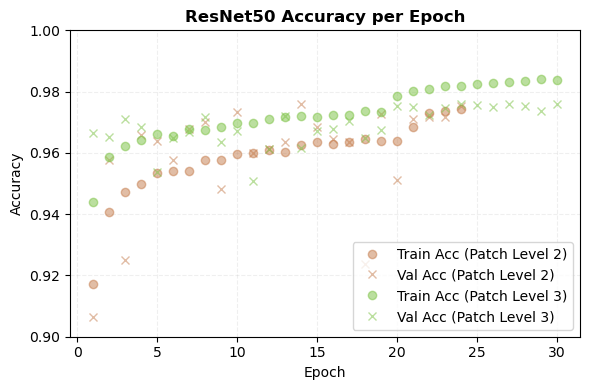

In [17]:
import matplotlib.pyplot as plt

# Accuracy values for ResNet50 on Patch Level 2
acc_patch2_train = [
    0.9173,
    0.9408,
    0.9471,
    0.9499,
    0.9535,
    0.9540,
    0.9542,
    0.9576,
    0.9578,
    0.9596,
    0.9599,
    0.9611,
    0.9604,
    0.9625,
    0.9634,
    0.9629,
    0.9634,
    0.9646,
    0.9640,
    0.9638,
    0.9686,
    0.9729,
    0.9738,
    0.9743,
]
acc_patch2_val = [
    0.9063,
    0.9576,
    0.9252,
    0.9657,
    0.9640,
    0.9578,
    0.9679,
    0.9700,
    0.9483,
    0.9732,
    0.9601,
    0.9612,
    0.9635,
    0.9759,
    0.9684,
    0.9646,
    0.9634,
    0.9237,
    0.9727,
    0.9512,
    0.9710,
    0.9717,
    0.9718,
    0.9754,
]

# Accuracy values for ResNet50 on Patch Level 3
acc_patch3_train = [
    0.9440,
    0.9585,
    0.9622,
    0.9641,
    0.9661,
    0.9656,
    0.9678,
    0.9676,
    0.9684,
    0.9696,
    0.9697,
    0.9709,
    0.9717,
    0.9722,
    0.9717,
    0.9724,
    0.9723,
    0.9737,
    0.9733,
    0.9785,
    0.9803,
    0.9810,
    0.9817,
    0.9819,
    0.9826,
    0.9827,
    0.9833,
    0.9834,
    0.9840,
    0.9839,
]
acc_patch3_val = [
    0.9665,
    0.9653,
    0.9711,
    0.9684,
    0.9537,
    0.9647,
    0.9667,
    0.9717,
    0.9637,
    0.9673,
    0.9508,
    0.9612,
    0.9719,
    0.9616,
    0.9672,
    0.9679,
    0.9703,
    0.9647,
    0.9675,
    0.9752,
    0.9750,
    0.9725,
    0.9748,
    0.9758,
    0.9755,
    0.9751,
    0.9760,
    0.9752,
    0.9738,
    0.9761,
]

# Plotting
plt.figure(figsize=(6, 4))
epochs2 = range(1, len(acc_patch2_train) + 1)
epochs3 = range(1, len(acc_patch3_train) + 1)

# Patch Level 2
plt.plot(
    epochs2,
    acc_patch2_train,
    color="#c47b4a7f",
    linestyle="",
    marker="o",
    label="Train Acc (Patch Level 2)",
)
plt.plot(
    epochs2,
    acc_patch2_val,
    color="#c47b4a7f",
    linestyle="",
    marker="x",
    label="Val Acc (Patch Level 2)",
)

# Patch Level 3
plt.plot(
    epochs3,
    acc_patch3_train,
    color="#80c44a87",
    linestyle="",
    marker="o",
    label="Train Acc (Patch Level 3)",
)
plt.plot(
    epochs3,
    acc_patch3_val,
    color="#80c44a87",
    linestyle="",
    marker="x",
    label="Val Acc (Patch Level 3)",
)

# Labels and formatting
plt.title("ResNet50 Accuracy per Epoch", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1)
plt.grid(True, linestyle="--", alpha=0.2)
plt.legend(loc="lower right")
plt.tight_layout()

# Save to PDF
plt.savefig("accuracy_resnet50_plot.pdf")
print("Plot saved to accuracy_plot.pdf")
plt.show()

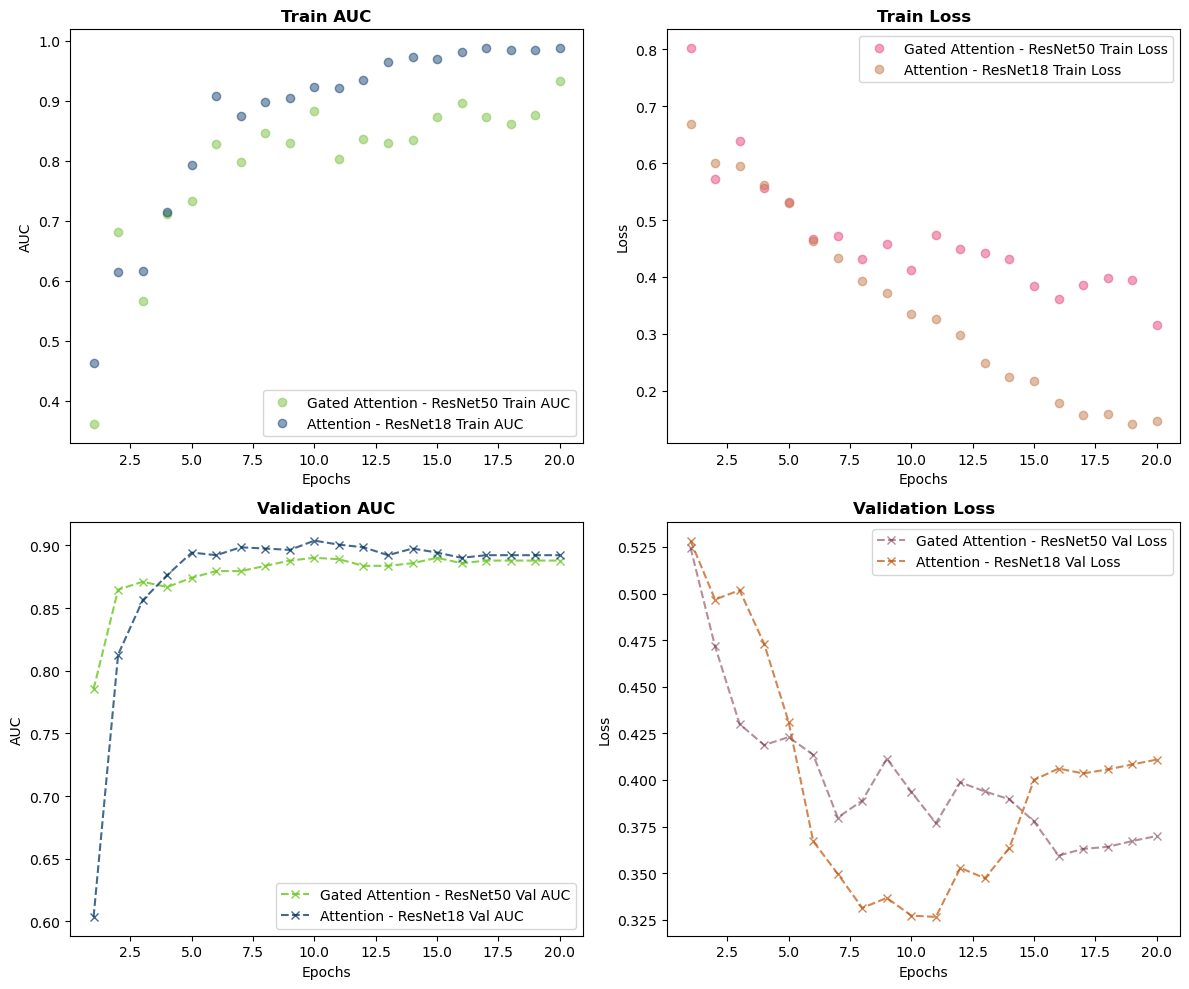

In [18]:
import pandas as pd
import os
import matplotlib.pyplot as plt

df1 = pd.read_csv(os.path.join(os.getcwd(), "mil_resnet50_gated_attention.csv"))
df2 = pd.read_csv(os.path.join(os.getcwd(), "mil_resnet18_attention.csv"))

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 10))


# Top-left: Train AUC of both models
axes[0, 0].plot(
    df1["epoch"],
    df1["train_auc"],
    color="#80c44a87",
    linestyle="",
    marker="o",
    label="Gated Attention - ResNet50 Train AUC",
)
axes[0, 0].plot(
    df2["epoch"],
    df2["train_auc"],
    color="#00336674",
    linestyle="",
    marker="o",
    label="Attention - ResNet18 Train AUC",
)
axes[0, 0].set_title("Train AUC", fontweight="bold")
axes[0, 0].set_xlabel("Epochs")
axes[0, 0].set_ylabel("AUC")
axes[0, 0].legend()

# Top-right: Train Loss of both models
axes[0, 1].plot(
    df1["epoch"],
    df1["train_loss"],
    color="#e7548088",
    linestyle="",
    marker="o",
    label="Gated Attention - ResNet50 Train Loss",
)
axes[0, 1].plot(
    df2["epoch"],
    df2["train_loss"],
    color="#c47b4a7f",
    linestyle="",
    marker="o",
    label="Attention - ResNet18 Train Loss",
)
axes[0, 1].set_title("Train Loss", fontweight="bold")
axes[0, 1].set_xlabel("Epochs")
axes[0, 1].set_ylabel("Loss")
axes[0, 1].legend()

# Bottom-left: Val AUC of both models
axes[1, 0].plot(
    df1["epoch"],
    df1["val_auc"],
    color="#71c929d8",
    linestyle="--",
    marker="x",
    label="Gated Attention - ResNet50 Val AUC",
)
axes[1, 0].plot(
    df2["epoch"],
    df2["val_auc"],
    color="#003366BC",
    linestyle="--",
    marker="x",
    label="Attention - ResNet18 Val AUC",
)
axes[1, 0].set_title("Validation AUC", fontweight="bold")
axes[1, 0].set_xlabel("Epochs")
axes[1, 0].set_ylabel("AUC")
axes[1, 0].legend()

# Bottom-right: Val Loss of both models
axes[1, 1].plot(
    df1["epoch"],
    df1["val_loss"],
    color="#70293f86",
    linestyle="--",
    marker="x",
    label="Gated Attention - ResNet50 Val Loss",
)
axes[1, 1].plot(
    df2["epoch"],
    df2["val_loss"],
    color="#c05914ba",
    linestyle="--",
    marker="x",
    label="Attention - ResNet18 Val Loss",
)
axes[1, 1].set_title("Validation Loss", fontweight="bold")
axes[1, 1].set_xlabel("Epochs")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("mil_comparison_attentions_plot.pdf")
plt.show()